In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
import joblib
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Bidirectional, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

In [2]:
url = 'https://raw.githubusercontent.com/panambY/Hourly_Energy_Consumption/master/data/PJM_Load_hourly.csv'
df = pd.read_csv(url)

In [3]:
data = df.iloc[:, 1].values.reshape(-1, 1)

In [4]:
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(data)

In [5]:
joblib.dump(scaler, 'scaler.pkl')

['scaler.pkl']

In [6]:
window_size = 48
X, y = [], []

In [7]:
for i in range(window_size, len(scaled_data)):
    X.append(scaled_data[i-window_size:i, 0])
    y.append(scaled_data[i, 0])

In [8]:
X, y = np.array(X), np.array(y)
X = np.reshape(X, (X.shape[0], X.shape[1], 1))

In [9]:
split_idx = int(len(X) * 0.8)
X_train, X_test = X[:split_idx], X[split_idx:]
y_train, y_test = y[:split_idx], y[split_idx:]

In [10]:
model = Sequential()
model.add(Bidirectional(LSTM(64, return_sequences=False), input_shape=(X_train.shape[1], 1)))
model.add(Dropout(0.2))
model.add(Dense(32, activation='relu'))
model.add(Dense(1))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/bidirectional.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [11]:
model.compile(optimizer='adam', loss='mse')

In [12]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ bidirectional (Bidirectional)   │ (None, 128)            │        33,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         4,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 37,953 (148.25 KB)

 Trainable params: 37,953 (148.25 KB)

 Non-trainable params: 0 (0.00 B)

In [13]:
early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

In [14]:
history = model.fit(
    X_train, y_train,
    epochs=20,
    batch_size=64,
    validation_data=(X_test, y_test),
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/20
411/411 ━━━━━━━━━━━━━━━━━━━━ 11s 14ms/step - loss: 0.0059 - val_loss: 0.0018
Epoch 2/20
411/411 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - loss: 0.0015 - val_loss: 9.4494e-04
Epoch 3/20
411/411 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - loss: 0.0011 - val_loss: 7.1590e-04
Epoch 4/20
411/411 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - loss: 9.0647e-04 - val_loss: 6.6766e-04
Epoch 5/20
411/411 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - loss: 8.0078e-04 - val_loss: 6.3095e-04
Epoch 6/20
411/411 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - loss: 7.4170e-04 - val_loss: 5.7735e-04
Epoch 7/20
411/411 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - loss: 6.9442e-04 - val_loss: 5.6117e-04
Epoch 8/20
411/411 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - loss: 6.7279e-04 - val_loss: 5.2091e-04
Epoch 9/20
411/411 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - loss: 6.5278e-04 - val_loss: 5.4442e-04
Epoch 10/20
411/411 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - loss: 6.2465e-04 - val_loss: 5.3290e-04
Epoch 11/20
411/411 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - loss: 5.9

Evaluating model performance on test data...
206/206 ━━━━━━━━━━━━━━━━━━━━ 5s 22ms/step

          AI MODEL ACCURACY REPORT          
Mean Absolute Error (MAE)  : 441.10 MW
Root Mean Squared Error(RMSE): 672.28 MW
R² Score (Accuracy Metric)   : 98.80%
Note: An R² score closer to 100% means a highly accurate model.



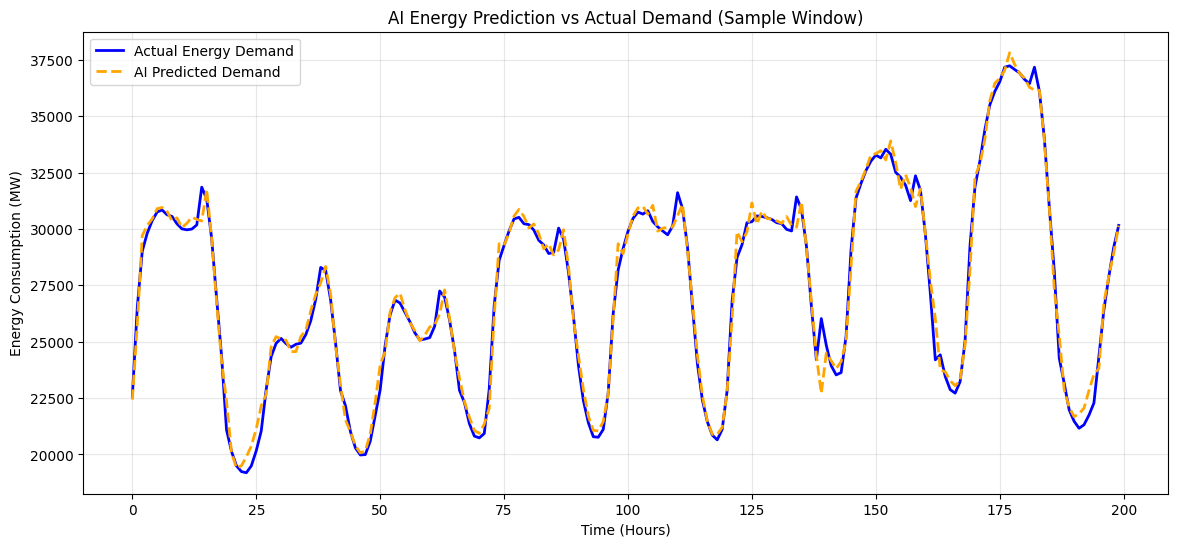

In [15]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

print("Evaluating model performance on test data...")

y_pred_scaled = model.predict(X_test)

y_pred = scaler.inverse_transform(y_pred_scaled)
y_actual = scaler.inverse_transform(y_test.reshape(-1, 1))

mae = mean_absolute_error(y_actual, y_pred)
mse = mean_squared_error(y_actual, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_actual, y_pred)

print("\n" + "="*40)
print("          AI MODEL ACCURACY REPORT          ")
print("="*40)
print(f"Mean Absolute Error (MAE)  : {mae:.2f} MW")
print(f"Root Mean Squared Error(RMSE): {rmse:.2f} MW")
print(f"R² Score (Accuracy Metric)   : {r2 * 100:.2f}%")
print("="*40)
print("Note: An R² score closer to 100% means a highly accurate model.\n")

plt.figure(figsize=(14, 6))
plt.plot(y_actual[:200], label='Actual Energy Demand', color='blue', linewidth=2)
plt.plot(y_pred[:200], label='AI Predicted Demand', color='orange', linestyle='--', linewidth=2)
plt.title('AI Energy Prediction vs Actual Demand (Sample Window)')
plt.xlabel('Time (Hours)')
plt.ylabel('Energy Consumption (MW)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

CHECKING IF THE MODEL IS OVERFIITING OR NOT

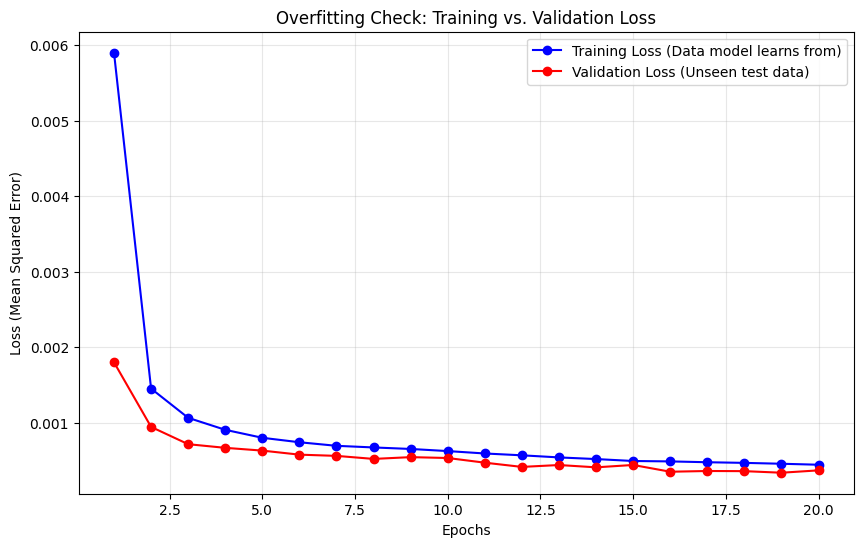

In [16]:
import matplotlib.pyplot as plt
train_loss = history.history['loss']
val_loss = history.history['val_loss']
epochs = range(1, len(train_loss) + 1)

plt.figure(figsize=(10, 6))
plt.plot(epochs, train_loss, 'bo-', label='Training Loss (Data model learns from)')
plt.plot(epochs, val_loss, 'ro-', label='Validation Loss (Unseen test data)')

plt.title('Overfitting Check: Training vs. Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss (Mean Squared Error)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

THE CURVE IS DECENFING PROPERLY S THE MODLE IS NOT OVERFITTING

In [17]:
model.save('urban_optimizer_model.keras')